In [27]:
import numpy as np
import scipy
from matplotlib import pyplot as plt
import time

# Constants
m    = 0.5
hbar = 1.0
w    = 1.0

The numerov propagator is:
$$\psi_{j+1}\left(1+\frac{h^2}{12}P_{j+1}\right)-2\psi_{j}\left(1-\frac{5h^2}{12}P_{j}\right)+\psi_{j-1}\left(1+\frac{h^2}{12}P_{j-1}\right)=0$$
Here,
$$P_{j}=\frac{2m}{\hbar^2}(E-V(x)).$$
Let's find what it looks like, written as a matrix.  Take
$$
\hat{A}=\frac{1}{h^2}
\begin{pmatrix}
    -2 &  1 &    &   & \\
     1 & -2 &  1 &   & \\
       &  1 & -2 & 1 & \\
       &    & \ddots & \ddots & \ddots
\end{pmatrix},
$$
and
$$
\hat{B}=\frac{1}{12}
\begin{pmatrix}
    10 &  1 &    &   & \\
     1 & 10 &  1 &   & \\
       &  1 & 10 & 1 & \\
       &    & \ddots & \ddots & \ddots
\end{pmatrix}.
$$
The with the potential and written as a diagonal matrix as usual, the propagator becomes
$$
\left(\hat{A}+\frac{2m}{\hbar^2}\hat{B}(E\hat{I}-\hat{V})\right)\psi=0.
$$
$\hat{I}$ is the identity matrix.  You can see where the factor of -2 in the $\psi_j$ term became a factor of 10 in combination with the fraction $-5/12$ to give the diagonal of $\hat{B}$.  $\hat{A}$ Is just the usual central difference stencil that we saw in the Crank-Nicholson, and $B$ is giving the extra Numerov correction that turns it into a locally $O(h^6)$ (globally $O(h^4)$) method!

The obvious way to solve this is to just immediately solve for $\psi$ by rearranging it into an eigenvalue problem:
$$
\left(-\frac{\hbar^2}{2m}\hat{B}^{-1}\hat{A}+\hat{V}\right)y=Ey.
$$
This is conceptually simple, but it's computationally a horrible idea because the inverse of a tridiagonal matrix, $\hat{B}^{-1}$, is a dense matrix.  That means that we end up using a full dense matrix diagonalization which is $O(N^3)$, compared to the $O(N)$ cost of working with tridiagonal matrices.  That's unacceptable.

Luckily, the equation in terms of the matrices is what's called a **generalized eigenvalue problem**, which you can see after rearranging the terms a bit:
$$
\left(-\frac{\hbar^2}{2m}\hat{A}+\hat{B}\hat{V}\right)y=E\hat{B}y.
$$
It's **generalized** in the sense that there are matrices on both sides of the equation, but luckily this isn't so computationally expensive.  It's **generalized** in the sense that there are matrices on both sides of the equation, but this isn't so computationally expensive (there is a ARPACK wrapper function `scipy.sparse.linalg.eigs` that is specifically designed for this exact situation, giving us an $O(N)$ solution).

In [2]:
# We need to specifically construct our matrices using scipy.sparse, 
#      so that we don't end up storing O(N^2) matrix elements in memory!
N  = 1000
xs = np.linspace(-10.0, 10.0, N)
h  = xs[1] - xs[0]

# Define the diagonals
# In class, we've done this as a for loop, but this is the 'smart' way to do it.
# We just define arrays that contain the diagonals of the matrix and put it together in one go
main_diag = -2.0 * np.ones(N)
off_diag = 1.0 * np.ones(N - 1) # The off-diagonals are one element shorter

# Build the sparse tridiagonal matrix A
A = (1 / h**2) * scipy.sparse.diags_array(
    [off_diag, main_diag, off_diag], 
    offsets = [-1, 0, 1], 
    format='csc' # 'csc' format is generally best for eigenvalue solvers
)

Since $\hat{A}$ is tridiagonal, we used a sparse representation, where the computer only stores the nonzero matrix elements.  This saves a TON of memory, and will also make the eigenvector/eigenvalue calculation MUCH faster.

In [3]:
# See that the matrix stores much fewer elements
print(A.__repr__, "\n")
print(f"As expected, we store only {3*N-2} elements in A, rather than {N**2}!")
print(f"This saves us {100.0*(1.0 - (3*N-2)/(N**2)):4.2f}% of the memory we'd otherwise use.")

<bound method _spbase.__repr__ of <Compressed Sparse Column sparse array of dtype 'float64'
	with 2998 stored elements and shape (1000, 1000)>> 

As expected, we store only 2998 elements in A, rather than 1000000!
This saves us 99.70% of the memory we'd otherwise use.


In [4]:
# Quickly assemble B as well.
main_diag = 10.0 * np.ones(N)
off_diag = 1.0 * np.ones(N - 1) # The off-diagonals are one element shorter

# Build the sparse tridiagonal matrix A
B = (1 / 12) * scipy.sparse.diags_array(
    [off_diag, main_diag, off_diag], 
    offsets = [-1, 0, 1], 
    format='csc' # 'csc' format is generally best for eigenvalue solvers
)

Let's quickly define our potential and our constants.  We're sticking with the harmonic oscillator for now, so
$$
V(x) = \frac{1}{2}m\omega^2x^2\ .
$$
As a matrix, it's just diagonal.
$$
V_{ij}=\frac{\delta_{ij}}{2}m\omega^2x_j^2\ .
$$

In [5]:
V = lambda x : 0.5 * m * (w**2) * (x**2)
V = scipy.sparse.diags_array(V(xs), format='csc')

At this point, we're ready to set up the generalized eigenvalue problem, which we saw was:
$$
\left(-\frac{\hbar^2}{2m}\hat{A}+\hat{B}\hat{V}\right)y=E\hat{B}y.
$$
Let's compute the LHS matrix:

In [6]:
LHS_matrix = -((hbar**2)/(2*m))*A + B @ V

It's a waste of computational power to compute ALL of the eigenvalues and eigenvectors, when we know that out of $N$ eigenvectors, all of them are going to be junk except for the ones corresponding to the lowest bound states.  Let's use the specialized solver, `scipy.sparse.linalg.eigs` to only calculate the bottom few eigenvalues.  It calls underlying FORTRAN code from ARPACK.

In [7]:
# k     = the number of lowest energy states you want to find (e.g., 3)
# M     = B sets up the generalized problem H*y = E*B*y
# sigma = 0.0 forces shift-invert mode to target the lowest eigenvalues
k = 5
evals, evecs = scipy.sparse.linalg.eigs(LHS_matrix, k=k, M=B, sigma=0.0)
evals = np.real(evals); evecs = np.real(evecs);

# The eigenvalues might not be perfectly sorted, so it's good practice to sort them
sort_indices = evals.argsort()
evals = evals[sort_indices]
evecs = evecs[:, sort_indices]

print(f"Lowest {k} Eigenvalues:")
for idx in range(k):
    Eexact = hbar * w * (idx + 0.5)
    print(f"n = {idx:2d}, calculated Eapprox = {evals[idx]:17.15f}, error = {(100.0 * np.abs(evals[idx] - Eexact) / Eexact):5.2e}%")


Lowest 5 Eigenvalues:
n =  0, calculated Eapprox = 0.499999999843126, error = 3.14e-08%
n =  1, calculated Eapprox = 1.499999998901826, error = 7.32e-08%
n =  2, calculated Eapprox = 2.499999996077954, error = 1.57e-07%
n =  3, calculated Eapprox = 3.499999990116242, error = 2.82e-07%
n =  4, calculated Eapprox = 4.499999979761537, error = 4.50e-07%


Great!  We have a working solver, it's giving us the correct eigenvalues.  Let's plot a few wavefunctions.

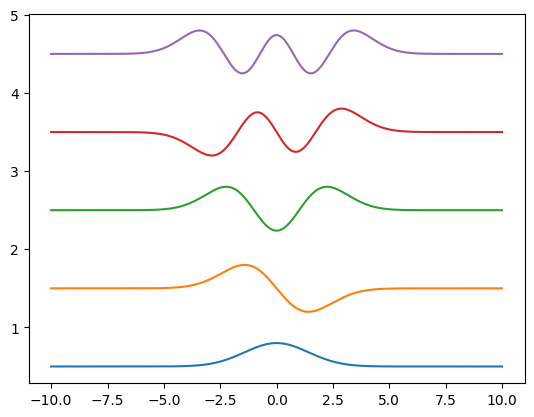

In [8]:
fig, ax = plt.subplots()

for idx in range(k):
    Eexact = hbar * w * (idx + 0.5)
    ax.plot(xs, Eexact + 0.3 * evecs[:, idx] / np.max(np.abs(evecs[:, idx])))

For the previous plot, I did a 'fake' normalization that looks nice.  However, we can do better than that.  The resultant wavefunctions can be normalized using the corrected trapezoidal rule that was discussed at the end of the week 3 lecture.

In [9]:
# Only works for uniform grid!
def trapz(xs, fs):
    h = xs[1] - xs[0]
    return h * (np.sum(fs[1:-1]) + 0.5 * (fs[0] + fs[-1]))
    
def cor_trapz(xs, fs):
    h = xs[1] - xs[0]
    # Forward difference for f'(a)
    fprime0    = (-fs[ 2] + 4.0*fs[ 1] - 3.0*fs[ 0]) / (2*h)
    fprime_end = ( fs[-3] - 4.0*fs[-2] + 3.0*fs[-1]) / (2*h)
    # Euler-Maclaurin formula requires subtracting the correction term
    return h * (np.sum(fs[1:-1]) + 0.5 * (fs[0] + fs[-1])) - (h**2)*(fprime_end - fprime0)/12.0

Let's quickly test the convergence of the corrected trapezoidal against the trapezoidal.

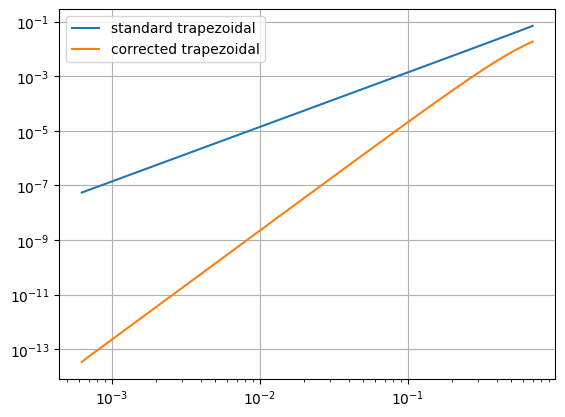

In [10]:
test_function = lambda x : np.exp(x) * (np.cos(x))**2
# We know the exact integral
exact = 3.0 * (np.exp(2.0*np.pi) - 1.0) / 5.0

test_Ns = np.int64(np.logspace(1, 4)) # must be integer
test_hs = []
errors_trapz = []
errors_cor_trapz = []

for tN in test_Ns:
    x = np.linspace(0.0, 2*np.pi, tN)
    test_hs.append(x[1] - x[0])
    integral_trapz     =     trapz(x, test_function(x))
    integral_cor_trapz = cor_trapz(x, test_function(x))
    errors_trapz.append(np.abs(integral_trapz - exact) / exact)
    errors_cor_trapz.append(np.abs(integral_cor_trapz - exact) / exact)

fig, ax = plt.subplots()
ax.plot(test_hs, errors_trapz, label = "standard trapezoidal")
ax.plot(test_hs, errors_cor_trapz, label = "corrected trapezoidal")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid()
ax.legend()

Clearly, the **global error** of the trapezoidal rule is not as good as with the corrected version.  The corrected trapezoidal rule is converging at $O(h^4)$ whereas the original trapezoidal rule only converges as $O(h^2)$.

We can already take Richardson extrapolation for a test run here!  With the corrected trapezoidal rule, we know that the final value of the integral, $F$ shows up as
$$
F_{\text{approx}}=F+\epsilon h^4\ ,
$$
where $\epsilon$ is the proportionality constant for the error.  If we try with two different grid sizes, we would have
$$
F_{\text{approx},\ 2h}=F+16\epsilon\ ,\qquad F_{\text{approx},\ h}=F+\epsilon\ ,
$$
so overall,
$$
F=\frac{16F_{\text{approx},\ h} - F_{\text{approx},\ 2h}}{15}
$$

In [11]:
test_function = lambda x : np.exp(x) * (np.cos(x))**2
# We know the exact integral
exact = 3.0 * (np.exp(2.0*np.pi) - 1.0) / 5.0
N_2h = 100
xs_2h = np.linspace(0.0, 2*np.pi,     N_2h)
xs_h  = np.linspace(0.0, 2*np.pi, 2 * N_2h)

result_h  = cor_trapz(xs_h, test_function(xs_h))
result_2h = cor_trapz(xs_2h, test_function(xs_2h))

richardson_extrapolation \
    = (16.0 * result_h - result_2h) / 15.0

print(f"Error without extrapolation: {(np.abs(result_h - exact) / exact):5.2e}")
print(f"Error with    extrapolation: {(np.abs(richardson_extrapolation - exact) / exact):5.2e}")

Error without extrapolation: 2.15e-07
Error with    extrapolation: 2.32e-11


With Richardson extrapolation of 100 samples, the final result becomes 10^4 times more accurate than the result without extrapolation!

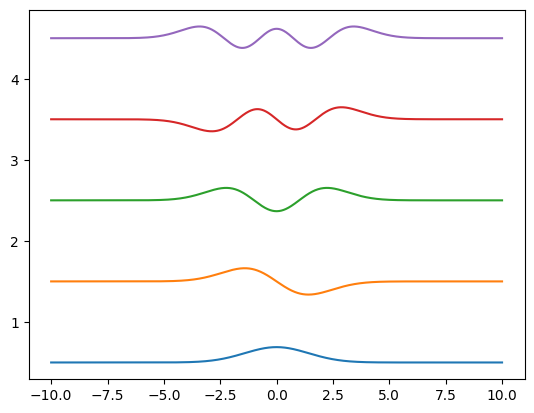

In [12]:
# If you even remember, the whole point of this side track was to normalize the wavefunction
fig, ax = plt.subplots()

for idx in range(k):
    Eexact = hbar * w * (idx + 0.5)
    norm = np.sqrt(cor_trapz(xs, np.abs(evecs[:, idx])**2))
    ax.plot(xs, Eexact + 0.3 * evecs[:, idx] / norm)

We have all of the ingredients to put together a single efficient matrix numerov function.  Let's do it!

In [13]:
def solve_numerov(V_func, x_start, x_end, N, m, hbar, k=5):
    xs = np.linspace(x_start, x_end, N)
    h = xs[1] - xs[0]
    
    off_diag = np.ones(N - 1)
    A = (1.0 / h**2) * scipy.sparse.diags_array(
        [off_diag, -2.0 * np.ones(N), off_diag], 
        offsets=[-1, 0, 1], format='csc'
    )
    B = (1.0 / 12.0) * scipy.sparse.diags_array(
        [off_diag, 10.0 * np.ones(N), off_diag], 
        offsets=[-1, 0, 1], format='csc'
    )
    
    V = scipy.sparse.diags_array(V_func(xs), format='csc')
    
    LHS_matrix = -(hbar**2 / (2 * m)) * A + B @ V
    
    # Solve for the k lowest eigenvalues using shift-invert mode (sigma=0.0)
    evals, evecs = scipy.sparse.linalg.eigs(LHS_matrix, k=k, M=B, sigma=0.0)
    evals = np.real(evals); evecs = np.real(evecs);
    sort_indices = evals.argsort()
    
    return xs, evals[sort_indices], evecs[:, sort_indices]

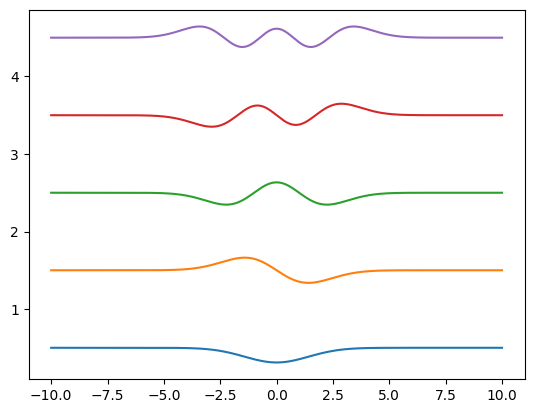

In [14]:
V = lambda x : 0.5 * m * (w**2) * (x**2)
xs, Es, psis = solve_numerov(V, -10.0, 10.0, 1000, m, hbar)

fig, ax = plt.subplots()

for idx in range(k):
    Eexact = hbar * w * (idx + 0.5)
    norm = np.sqrt(cor_trapz(xs, np.abs(psis[:, idx])**2))
    ax.plot(xs, Es[idx] + 0.3 * psis[:, idx] / norm)

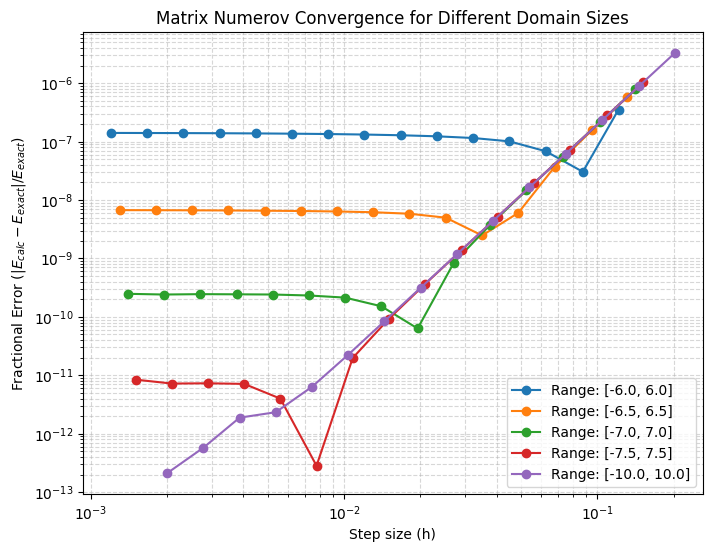

In [26]:
# Range of grid points to test
test_Ns = np.int64(np.logspace(2, 4, 15)) 

# Ground state exact energy
E_exact_0 = hbar * w * 0.5

# Define the different x ranges to test
x_ranges = [(-6.0, 6.0), (-6.5, 6.5), (-7.0, 7.0), (-7.5, 7.5), (-10.0, 10.0)]

fig, ax = plt.subplots(figsize=(8, 6))

first_hs = None
first_errors = None

# Loop over each domain range
for (x_start, x_end) in x_ranges:
    hs = []
    errors = []
    
    for tN in test_Ns:
        # Solve for just the lowest state to save time (k=1)
        xs, Es, psis = solve_numerov(V, x_start, x_end, tN, m, hbar, k=1)
        
        h = xs[1] - xs[0]
        hs.append(h)
        
        # Calculate fractional error for the ground state
        err = np.abs(Es[0] - E_exact_0) / E_exact_0
        errors.append(err)
        
    hs = np.array(hs)
    errors = np.array(errors)
        
    # Plot the actual error for this range
    ax.plot(hs, errors, 'o-', label=f"Range: [{x_start}, {x_end}]")

# Format the plot
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Step size (h)")
ax.set_ylabel("Fractional Error ($|E_{calc} - E_{exact}| / E_{exact}$)")
ax.set_title("Matrix Numerov Convergence for Different Domain Sizes")
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend()

plt.show()

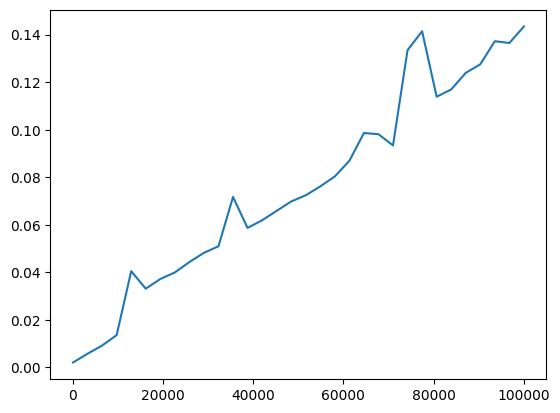

In [41]:
# Define the range of grid sizes (N) to test, e.g., from 100 to 10,000
N_test_vals = np.int64(np.linspace(100, 100000, 32))
run_times = []

# Ensure we use the harmonic oscillator potential defined earlier
V_func = lambda x : 0.5 * m * (w**2) * (x**2)

for test_N in N_test_vals:
    start_time = time.perf_counter()
    
    # Solve for the lowest 5 states
    solve_numerov(V_func, -10.0, 10.0, test_N, m, hbar, k=5)
    
    end_time = time.perf_counter()
    run_times.append(end_time - start_time)

run_times = np.array(run_times)

fig, ax = plt.subplots()

# Plot the measured execution times
ax.plot(N_test_vals, run_times, '-',)

plt.show()

Runtime scaling of the matrix Numerov:  it's linear!